In [2]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection         import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing           import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.pipeline                import Pipeline
from sklearn.metrics                 import (accuracy_score, f1_score,
                                              classification_report,
                                              confusion_matrix)
from imblearn.over_sampling          import SMOTE
from imblearn.pipeline               import Pipeline as ImbPipeline


In [22]:
# ════════════════════════════════════════════════════════════════════════════
#  LOAD RAW DATA
# ════════════════════════════════════════════════════════════════════════════
df = pd.read_csv("mtsamples.csv")
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df["medical_specialty"] = df["medical_specialty"].str.strip()

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head(3)

Shape   : (4999, 5)
Columns : ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [23]:
# ════════════════════════════════════════════════════════════════════════════
# DATA EXPLORATION
# ════════════════════════════════════════════════════════════════════════════
print("── Null counts ──")
print(df.isnull().sum())

print("\n── Unique specialties ──")
print(f"{df['medical_specialty'].nunique()} specialties")

print("\n── Samples per specialty ──")
print(df["medical_specialty"].value_counts().to_string())

── Null counts ──
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

── Unique specialties ──
40 specialties

── Samples per specialty ──
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management              

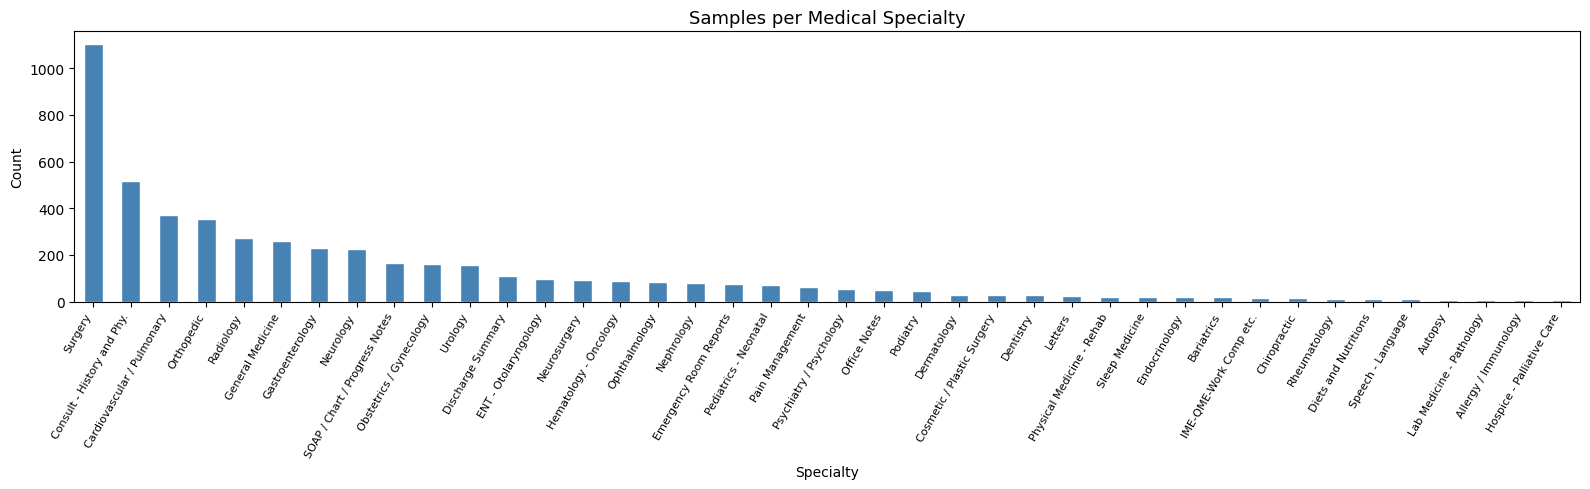


Largest class : Surgery  → 1103 samples
Smallest class: Hospice - Palliative Care  → 6 samples
Imbalance ratio: 184x


In [24]:
# ════════════════════════════════════════════════════════════════════════════
# PLOT CLASS DISTRIBUTION
# ════════════════════════════════════════════════════════════════════════════
counts = df["medical_specialty"].value_counts()

plt.figure(figsize=(16, 5))
counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Samples per Medical Specialty", fontsize=13)
plt.xlabel("Specialty")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

print(f"\nLargest class : {counts.idxmax()}  → {counts.max()} samples")
print(f"Smallest class: {counts.idxmin()}  → {counts.min()} samples")
print(f"Imbalance ratio: {counts.max() / counts.min():.0f}x")

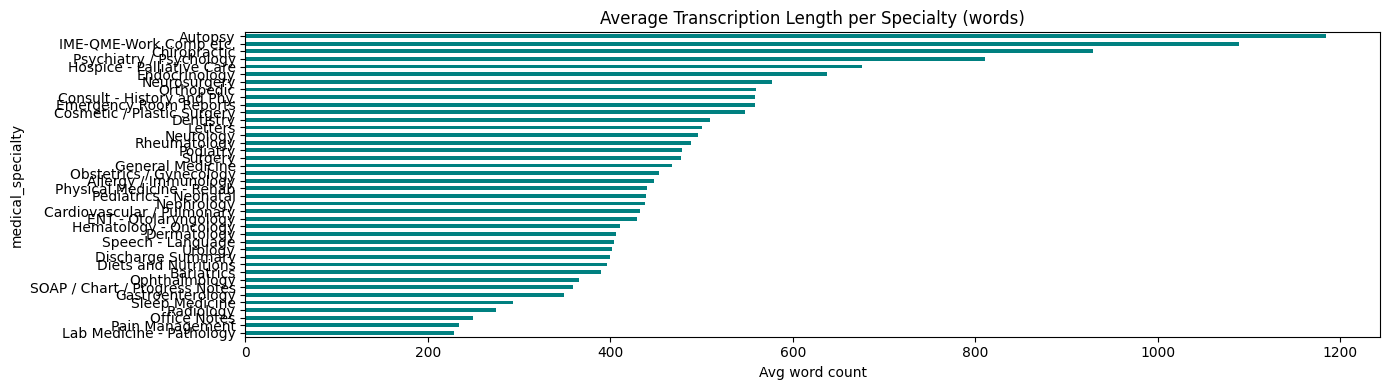

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: word_count, dtype: float64


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# TEXT LENGTH ANALYSIS
# ════════════════════════════════════════════════════════════════════════════
df["word_count"] = df["transcription"].fillna("").str.split().str.len()

plt.figure(figsize=(14, 4))
df.groupby("medical_specialty")["word_count"].mean().sort_values().plot(
    kind="barh", color="teal"
)
plt.title("Average Transcription Length per Specialty (words)")
plt.xlabel("Avg word count")
plt.tight_layout()
plt.savefig("text_length.png", dpi=150)
plt.show()

print(df["word_count"].describe())

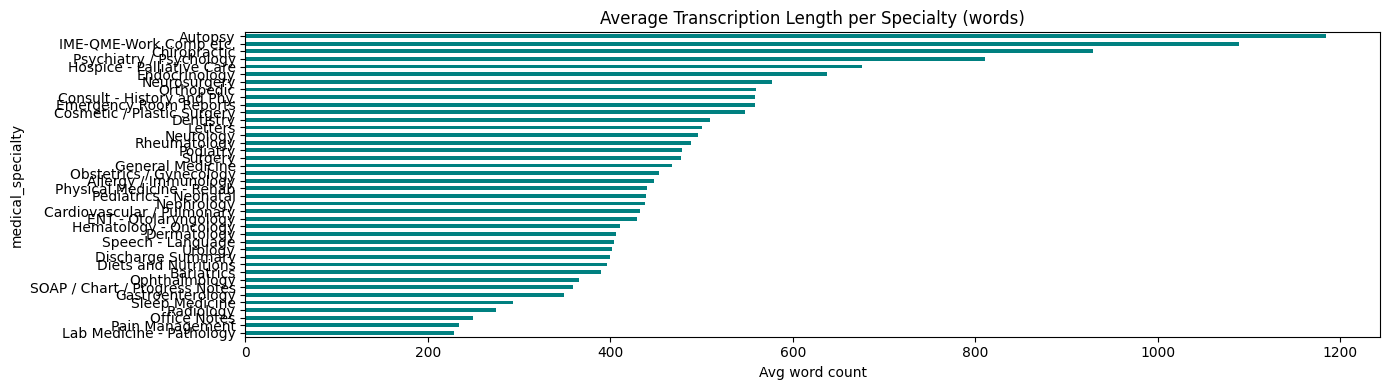

count    4999.000000
mean      462.376275
std       317.585206
min         0.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: word_count, dtype: float64


In [25]:
df["word_count"] = df["transcription"].fillna("").str.split().str.len()

plt.figure(figsize=(14, 4))
df.groupby("medical_specialty")["word_count"].mean().sort_values().plot(
    kind="barh", color="teal"
)
plt.title("Average Transcription Length per Specialty (words)")
plt.xlabel("Avg word count")
plt.tight_layout()
plt.savefig("text_length.png", dpi=150)
plt.show()

print(df["word_count"].describe())

In [26]:
# ════════════════════════════════════════════════════════════════════════════
# TEXT PREPROCESSING
#
# Concept: Raw clinical text is noisy.
#   • Numbers don't distinguish specialties — replace with NUM token
#   • Punctuation adds no semantic value for bag-of-words models
#   • Generic medical words ("patient", "history") appear everywhere
#     and dilute the TF-IDF signal — remove them
# ════════════════════════════════════════════════════════════════════════════

CUSTOM_STOPWORDS = {
    "patient", "history", "procedure", "diagnosis", "physician",
    "doctor", "hospital", "year", "old", "also", "using", "used",
    "right", "left", "noted", "placed", "performed", "following",
    "general", "medical", "normal", "well", "without", "within",
    "name", "date", "time", "mm", "mg", "cm",
}

def clean_text(text: str) -> str:
    """
    Normalise a raw transcription string.
    Pipeline:
      1. Lowercase
      2. Replace digits with NUM
      3. Strip punctuation
      4. Remove single-char tokens
      5. Remove domain-generic stopwords
    """
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " NUM ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split()
              if len(t) > 1 and t not in CUSTOM_STOPWORDS]
    return " ".join(tokens)


# Combine transcription + description for richer input
df["combined_text"] = (
    df["transcription"].fillna("") + " " + df["description"].fillna("")
)
df["clean_text"] = df["combined_text"].apply(clean_text)

# Drop rows with no usable text after cleaning (the 33 null transcriptions)
before = len(df)
df = df[df["clean_text"].str.len() > 30].reset_index(drop=True)
print(f"Dropped {before - len(df)} rows. Remaining: {len(df)}")

# Sanity check — before vs after
idx = 10
print("\n── Raw text (first 300 chars) ──")
print(df["combined_text"].iloc[idx][:300])
print("\n── Cleaned text (first 300 chars) ──")
print(df["clean_text"].iloc[idx][:300])

Dropped 12 rows. Remaining: 4987

── Raw text (first 300 chars) ──
PREOPERATIVE DIAGNOSIS: , Morbid obesity. ,POSTOPERATIVE DIAGNOSIS: , Morbid obesity. ,PROCEDURE:,  Laparoscopic Roux-en-Y gastric bypass, antecolic, antegastric with 25-mm EEA anastamosis, esophagogastroduodenoscopy. ,ANESTHESIA: , General with endotracheal intubation. ,INDICATIONS FOR PROCEDURE: ,

── Cleaned text (first 300 chars) ──
preoperative morbid obesity postoperative morbid obesity laparoscopic roux en gastric bypass antecolic antegastric with eea anastamosis esophagogastroduodenoscopy anesthesia with endotracheal intubation indications for this is male who has been overweight for many years and has tried multiple differ


In [27]:
# ════════════════════════════════════════════════════════════════════════════
# SHARED CSV FOR TEAMMATE
# This file contains the original columns + clean_text + word_count.
# ════════════════════════════════════════════════════════════════════════════
cols_to_save = [
    "description",
    "medical_specialty",
    "sample_name",
    "transcription",
    "keywords",
    "clean_text",
    "word_count",
]
df[cols_to_save].to_csv("mtsamples_clean.csv", index=False, encoding="utf-8-sig")
print("Saved → mtsamples_clean.csv")
print(f"  Rows    : {len(df)}")
print(f"  Columns : {cols_to_save}")

Saved → mtsamples_clean.csv
  Rows    : 4987
  Columns : ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'clean_text', 'word_count']


In [36]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL ENCODING + TRAIN / VAL / TEST SPLIT
# Concept: Stratified split preserves class ratios in every partition.
#   Without stratify=y, rare classes might land entirely in test
#   and the model never learns them.
# Split: 70% train | 15% val | 15% test
# ════════════════════════════════════════════════════════════════════════════
df["label_merged"] = df["medical_specialty"].apply(
    lambda x: x if df["medical_specialty"].value_counts()[x] >= 20 else "Other"
)
print(df["label_merged"].value_counts())
print(f"Classes after merge: {df['label_merged'].nunique()}")

le = LabelEncoder()
y  = le.fit_transform(df["label_merged"])
X  = df["clean_text"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"Train:{len(X_train)}  Val:{len(X_val)}  Test:{len(X_test)}")

label_merged
Surgery                          1098
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  228
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           157
Other                             125
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       50
Podiatry                           47
Dermatology                        29
Cosmetic / Plastic Surgery         27

In [33]:
# ════════════════════════════════════════════════════════════════════════════
# TF-IDF FEATURE EXTRACTION
# Concept:
#   TF  (Term Frequency)   = how often word w appears in document d
#   IDF (Inverse Doc Freq) = log(N / df_w) — penalises common words
#   TF-IDF = TF × IDF      — high score = word is distinctive to THIS doc
#   ngram_range=(1,2) : single words AND two-word phrases
#                       e.g. "chest pain", "knee replacement"
#   sublinear_tf=True : applies log(1+TF) — dampens very frequent terms
#   max_features      : keeps the 60k most informative tokens
#   min_df=2          : ignores terms appearing in only 1 document
# ════════════════════════════════════════════════════════════════════════════

def make_tfidf():
    return TfidfVectorizer(ngram_range=(1,2), max_features=60000,
                           sublinear_tf=True, min_df=2)

In [40]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL A: LOGISTIC REGRESSION
# Concept:
#   Learns one weight vector w_k per class k.
#   Prediction: argmax_k  softmax(W · x)_k
#   class_weight="balanced" scales loss by inverse class frequency —
#   so a wrong prediction on a rare class costs more than on Surgery.
# ════════════════════════════════════════════════════════════════════════════
# CELL 11 — LR pipeline
lr_pipe = Pipeline([
    ("tfidf", make_tfidf()),
    ("clf", LogisticRegression(C=1.0, max_iter=1000,
             class_weight="balanced", solver="liblinear", random_state=42)),
])
lr_pipe.fit(X_train, y_train)
lr_val_preds = lr_pipe.predict(X_val)
print(f"LR  Accuracy:{accuracy_score(y_val,lr_val_preds):.4f}  Macro-F1:{f1_score(y_val,lr_val_preds,average='macro',zero_division=0):.4f}")

LR  Accuracy:0.2861  Macro-F1:0.3186


**Model Observation**

Logistic Regression consistently achieved ~0.30 accuracy across multiple solvers, indicating it struggles to converge on a 60k-feature sparse TF-IDF matrix with 40 classes.  

This motivated the switch to **LinearSVC**, which uses coordinate descent directly on sparse data and is the standard choice for high-dimensional text classification.

In [39]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL B: LINEAR SVC
#
# Concept:
#   Finds a hyperplane w·x + b = 0 that separates classes with maximum
#   margin. C = trade-off between margin width and misclassifications.
#   Large C → tries hard to classify everything correctly (risk: overfit)
#   Small C → allows more errors for a wider, more general margin
# ════════════════════════════════════════════════════════════════════════════
svc_pipe = Pipeline([
    ("tfidf", make_tfidf()),
    ("clf", LinearSVC(C=1.0, class_weight="balanced",
                      max_iter=5000, random_state=42)),
])
svc_pipe.fit(X_train, y_train)
svc_val_preds = svc_pipe.predict(X_val)
print(f"SVC Accuracy:{accuracy_score(y_val,svc_val_preds):.4f}  Macro-F1:{f1_score(y_val,svc_val_preds,average='macro',zero_division=0):.4f}")

SVC Accuracy:0.1444  Macro-F1:0.1948


In [21]:
# ── DIAGNOSTIC CELL — paste and run this immediately ─────────────────────
# We need to find exactly where the pipeline is broken.

print("=" * 55)
print("CHECK 1 — TF-IDF matrix")
print("=" * 55)
print(f"  Train shape : {X_train_tfidf.shape}")
print(f"  Val shape   : {X_val_tfidf.shape}")
print(f"  Non-zero entries (train) : {X_train_tfidf.nnz}")
print(f"  Avg non-zeros per doc    : {X_train_tfidf.nnz / X_train_tfidf.shape[0]:.1f}")
# Expected: shape (3486, 60000), nnz > 1,000,000, avg > 300
# If nnz is very low (< 100,000) → TF-IDF is broken
# If avg < 50 → clean_text is stripping too much

print()
print("=" * 55)
print("CHECK 2 — Label arrays")
print("=" * 55)
print(f"  y_train unique classes : {len(set(y_train))}")
print(f"  y_val unique classes   : {len(set(y_val))}")
print(f"  y_train sample (first 10): {y_train[:10]}")
print(f"  y_val sample   (first 10): {y_val[:10]}")
# Expected: 40 unique classes in both
# If only 1 class → label encoding failed

print()
print("=" * 55)
print("CHECK 3 — Sample clean_text")
print("=" * 55)
for i in [0, 1, 2]:
    txt = X_train[i]
    print(f"  Sample {i} ({len(txt.split())} words): {txt[:120]}...")
    print()
# Expected: readable medical words, 50+ words per sample
# If empty or very short → clean_text stripped everything

print()
print("=" * 55)
print("CHECK 4 — Dummy classifier baseline")
print("=" * 55)
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_tfidf, y_train)
dummy_acc = accuracy_score(y_val, dummy.predict(X_val_tfidf))
print(f"  Dummy (most_frequent) accuracy: {dummy_acc:.4f}")
# Expected: ~0.21 (Surgery is ~21% of data)
# CRITICAL: if SVC accuracy < dummy accuracy → labels and features are misaligned

print()
print("=" * 55)
print("CHECK 5 — Are X and y aligned?")
print("=" * 55)
print(f"  len(X_train) : {len(X_train)}")
print(f"  len(y_train) : {len(y_train)}")
print(f"  len(X_val)   : {len(X_val)}")
print(f"  len(y_val)   : {len(y_val)}")
# Expected: X and y lengths must match exactly

CHECK 1 — TF-IDF matrix
  Train shape : (3490, 60000)
  Val shape   : (748, 60000)
  Non-zero entries (train) : 1507821
  Avg non-zeros per doc    : 432.0

CHECK 2 — Label arrays
  y_train unique classes : 40
  y_val unique classes   : 40
  y_train sample (first 10): [19 38  3  3 33 14  5 11  3 38]
  y_val sample   (first 10): [21 27 32 38 38 38 14 27 38  5]

CHECK 3 — Sample clean_text
  Sample 0 (68 words): gross description specimen labeled sesamoid bone foot is received in formalin and consists of three irregular fragments ...

  Sample 1 (366 words): extracapsular cataract extraction with posterior chamber intraocular lens placement by phacoemulsification anesthesia pe...

  Sample 2 (123 words): reason for examination abnormal ekg findings the was exercised according to standard bruce protocol for minutes achievin...


CHECK 4 — Dummy classifier baseline
  Dummy (most_frequent) accuracy: 0.2206

CHECK 5 — Are X and y aligned?
  len(X_train) : 3490
  len(y_train) : 3490
  len(X_va